# Options Pricing Analysis

This notebook compares three pricing methods for European options:

- Black-Scholes
- Binomial Tree
- Monte Carlo Simulation

It also explores convergence behaviour and sensitivity to key parameters such as stock price and volatility.Analysis 

In [32]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import numpy as np
import matplotlib.pyplot as plt

from models.black_scholes import black_scholes_price
from models.binomial import binomial_price
from models.monte_carlo import monte_carlo_price
from greeks.greeks import black_scholes_greeks
from visualisation.comparison_plots import (
    plot_binomial_convergence,
    plot_monte_carlo_convergence,
    plot_model_comparison,
)
from visualisation.sensitivity_plots import (
    plot_price_vs_stock,
    plot_price_vs_volatility,
    plot_delta_vs_stock,
    plot_vega_vs_volatility,
)
from visualisation.payoff_plots import plot_payoff

In [33]:
# Base option parameters
S = 42
K = 40
T = 0.5
r = 0.05
sigma = 0.2
option_type = "put"

# Numerical model settings
steps = 100
simulations = 100000
seed = 42

In [34]:
print(f"Option type: {option_type}")
print(f"Stock price (S): {S}")
print(f"Strike price (K): {K}")
print(f"Time to expiry (T): {T}")
print(f"Risk-free rate (r): {r}")
print(f"Volatility (sigma): {sigma}")
print(f"Binomial steps: {steps}")
print(f"Monte Carlo simulations: {simulations}")

Option type: put
Stock price (S): 42
Strike price (K): 40
Time to expiry (T): 0.5
Risk-free rate (r): 0.05
Volatility (sigma): 0.2
Binomial steps: 100
Monte Carlo simulations: 100000


## Model Price Comparison

The same option is priced using all three methods.

In [35]:
bs_price = black_scholes_price(option_type, S, K, T, r, sigma)
bin_price = binomial_price(option_type, S, K, T, r, sigma, steps)
mc_price = monte_carlo_price(option_type, S, K, T, r, sigma, simulations, seed=seed)

print(f"Black-Scholes: {bs_price:.6f}")
print(f"Binomial:      {bin_price:.6f}")
print(f"Monte Carlo:   {mc_price:.6f}")
print()
print(f"Binomial error vs Black-Scholes:    {abs(bs_price - bin_price):.6f}")
print(f"Monte Carlo error vs Black-Scholes: {abs(bs_price - mc_price):.6f}")

Black-Scholes: 1.092900
Binomial:      1.095825
Monte Carlo:   1.093245

Binomial error vs Black-Scholes:    0.002925
Monte Carlo error vs Black-Scholes: 0.000346


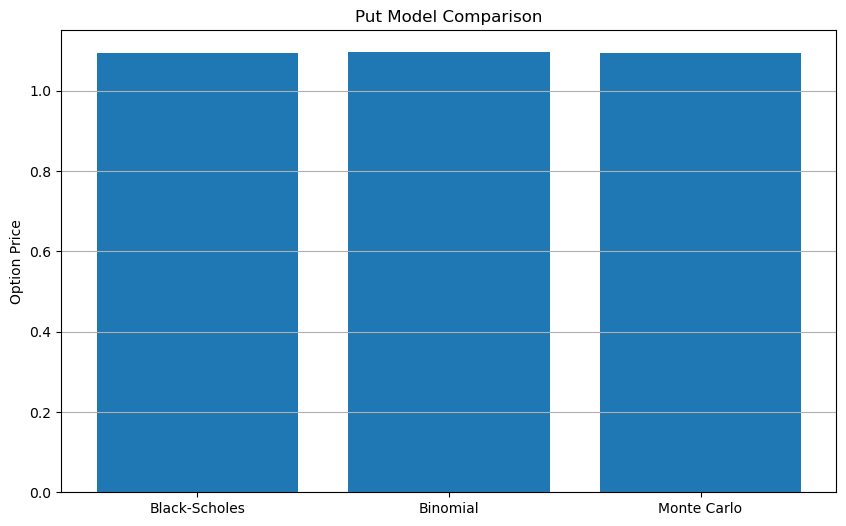

In [36]:
plot_model_comparison(option_type, S, K, T, r, sigma, steps, simulations, seed=seed)

### Observation

For this European option, Black-Scholes provides the analytical benchmark.  
Binomial and Monte Carlo both produce prices that are close to the Black-Scholes value, with small approximation error.

## Binomial Convergence

This section investigates how the binomial tree price changes as the number of steps increases.

In [37]:
steps_list = [5, 10, 25, 50, 100, 200, 500, 1000]

for n_steps in steps_list:
    price = binomial_price(option_type, S, K, T, r, sigma, n_steps)
    error = abs(bs_price - price)
    print(f"Steps={n_steps:<4} Price={price:.6f} Error={error:.6f}")

Steps=5    Price=1.080817 Error=0.012082
Steps=10   Price=1.141640 Error=0.048741
Steps=25   Price=1.108509 Error=0.015610
Steps=50   Price=1.095911 Error=0.003012
Steps=100  Price=1.095825 Error=0.002925
Steps=200  Price=1.095219 Error=0.002320
Steps=500  Price=1.092858 Error=0.000041
Steps=1000 Price=1.093372 Error=0.000472


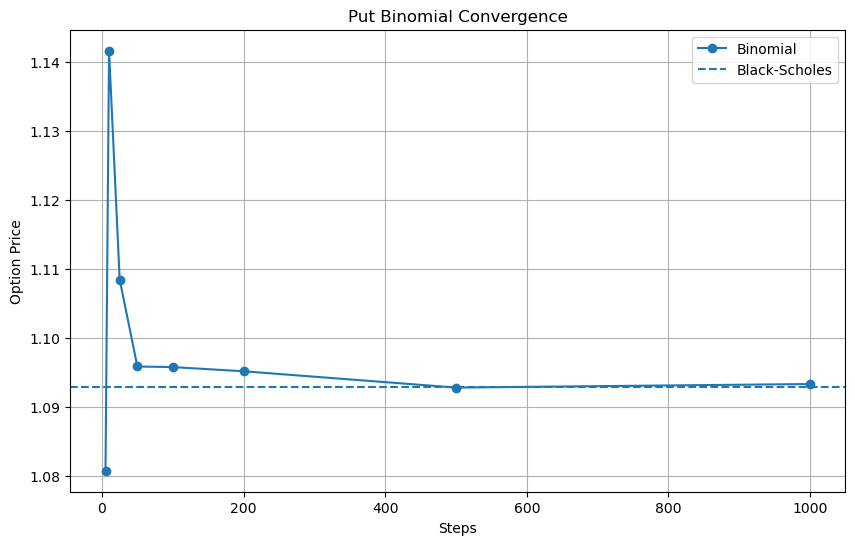

In [38]:
plot_binomial_convergence(option_type, S, K, T, r, sigma, steps_list)

### Observation

As the number of binomial steps increases, the binomial price converges towards the Black-Scholes value.  
This is expected because a finer tree provides a better discrete approximation to the continuous-time model.

## Monte Carlo Convergence

This section investigates how the Monte Carlo estimate behaves as the number of simulations increases.

In [39]:
simulations_list = [100, 1000, 5000, 10000, 50000, 100000, 200000]

for n_sims in simulations_list:
    price = monte_carlo_price(option_type, S, K, T, r, sigma, n_sims, seed=seed)
    error = abs(bs_price - price)
    print(f"Simulations={n_sims:<6} Price={price:.6f} Error={error:.6f}")

Simulations=100    Price=1.078386 Error=0.014514
Simulations=1000   Price=1.012195 Error=0.080704
Simulations=5000   Price=1.080418 Error=0.012482
Simulations=10000  Price=1.100295 Error=0.007396
Simulations=50000  Price=1.095030 Error=0.002131
Simulations=100000 Price=1.093245 Error=0.000346
Simulations=200000 Price=1.092187 Error=0.000713


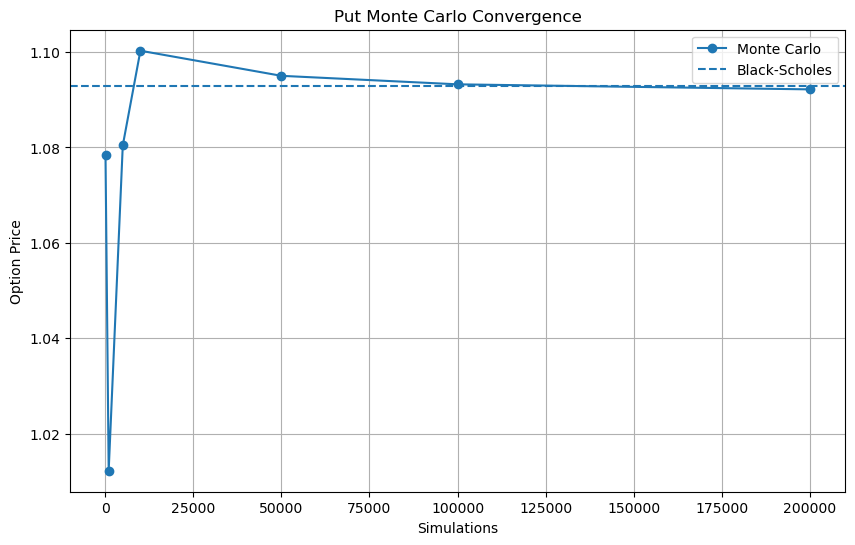

In [40]:
plot_monte_carlo_convergence(option_type, S, K, T, r, sigma, simulations_list, seed=seed)

### Observation

Monte Carlo estimates are noisier at low simulation counts but become more stable as the number of simulations increases.  
Unlike Black-Scholes, Monte Carlo is approximate and depends on random sampling, but it is highly flexible for more complex derivatives.

## Greeks

The Greeks measure how sensitive the option price is to changes in the underlying inputs.

In [47]:
delta, theta, rho, gamma, vega = black_scholes_greeks(option_type, S, K, T, r, sigma)

print(f"Delta: {delta:.6f}")
print(f"Gamma: {gamma:.6f}")
print(f"Vega:  {vega:.6f}")
print(f"Theta: {theta:.6f}")
print(f"Rho:   {rho:.6f}")

Delta: -0.276763
Gamma: 0.056353
Vega:  9.940703
Theta: -1.352294
Rho:   -6.358465


### Interpretation

- **Delta** measures sensitivity to changes in stock price.
- **Gamma** measures how Delta changes as stock price changes.
- **Vega** measures sensitivity to volatility.
- **Theta** measures time decay.
- **Rho** measures sensitivity to interest rates.

## Sensitivity Analysis

The following plots show how option value and Greeks change as key inputs vary.

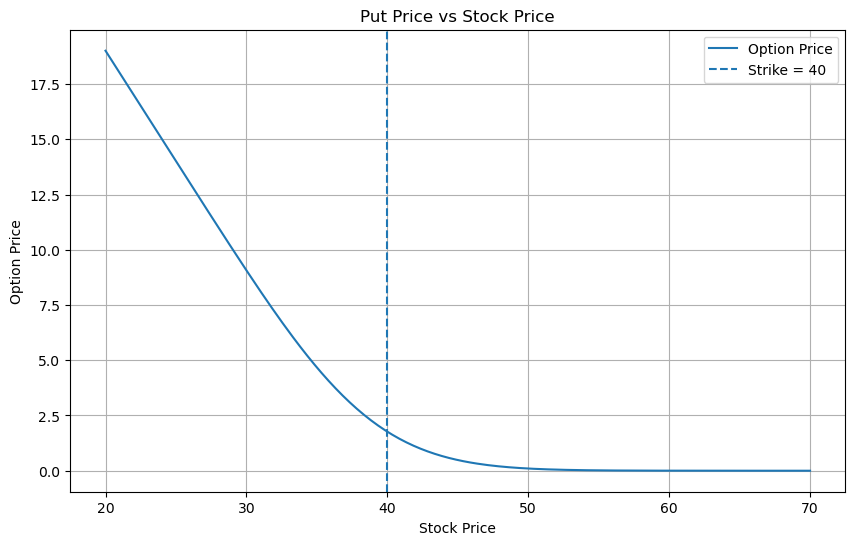

In [48]:
plot_price_vs_stock(option_type, K, T, r, sigma, stock_min=20, stock_max=70)

### Observation

The option price changes non-linearly with stock price.  
For puts, value generally decreases as the stock price rises, since the right to sell at the strike becomes less valuable.

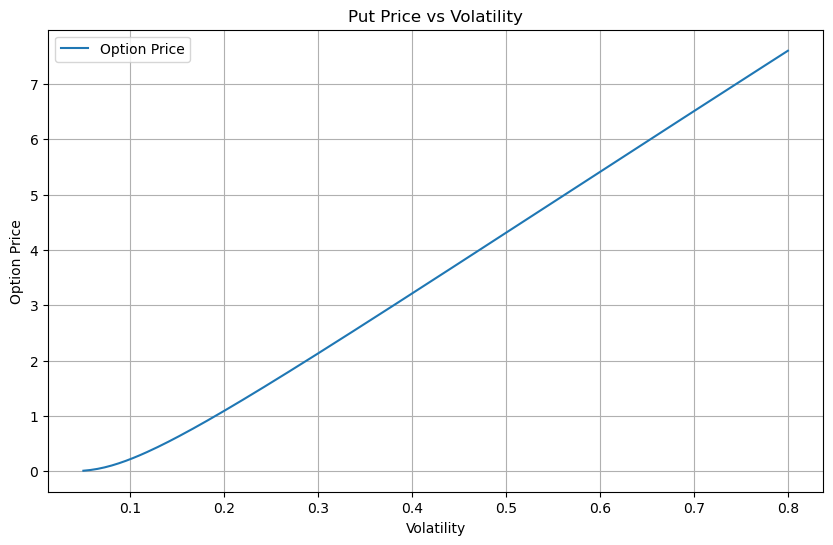

In [49]:
plot_price_vs_volatility(option_type, S, K, T, r, vol_min=0.05, vol_max=0.8)

### Observation

Option value increases as volatility rises.  
Higher volatility increases uncertainty, which raises the probability of favourable outcomes for the option holder.

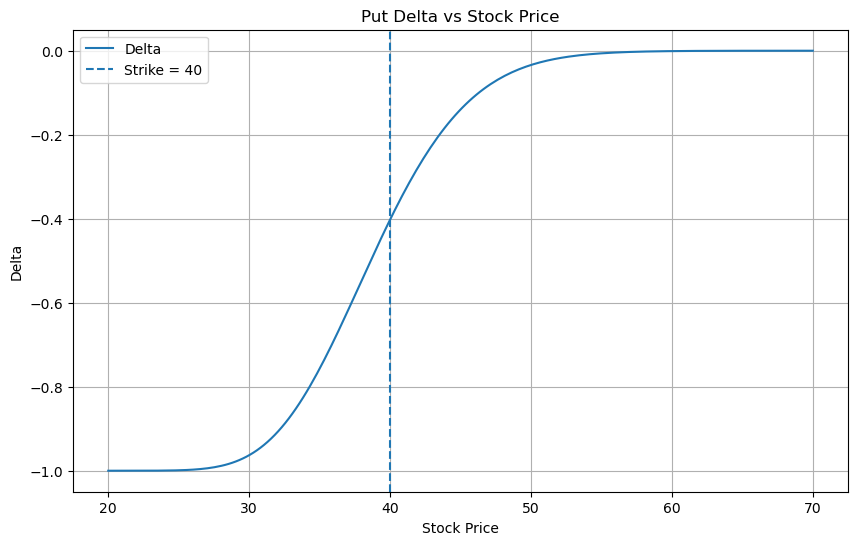

In [50]:
plot_delta_vs_stock(option_type, K, T, r, sigma, stock_min=20, stock_max=70)

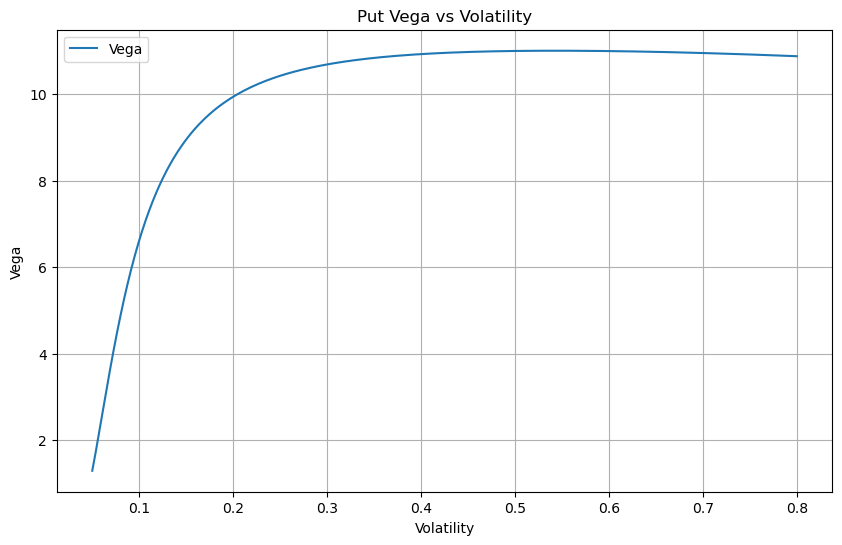

In [51]:
plot_vega_vs_volatility(option_type, S, K, T, r, vol_min=0.05, vol_max=0.8)

## Payoff at Expiry

This plot shows the profit/loss profile of the option at expiry.

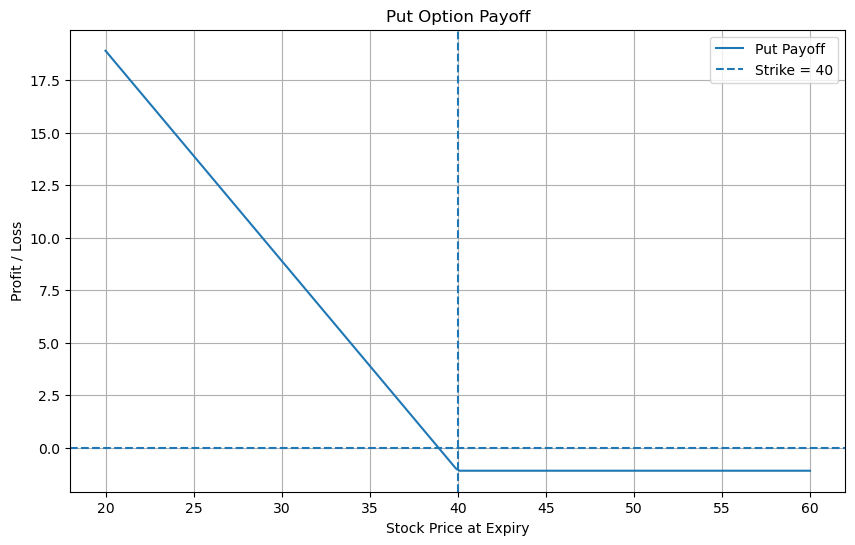

In [52]:
plot_payoff(option_type, K, premium=bs_price)

### Observation

The payoff diagram illustrates the asymmetric nature of options.  
The maximum loss is limited to the premium paid, while gains depend on how favourably the underlying asset moves relative to the strike.

## Conclusion

This notebook compared three methods for pricing European options:

- Black-Scholes provided the analytical benchmark
- Binomial pricing converged towards Black-Scholes as the number of steps increased
- Monte Carlo pricing became more stable as the number of simulations increased

The results also showed how option value depends strongly on stock price, volatility, and time-related sensitivities captured by the Greeks.